## Sprint 2 — Modelos Baseline y Collaborative Filtering
## RetailRocket Recommender System
**Equipo:** NexusDataCo | **Bootcamp:** SoyHenry Data Science

**Objetivo:** Entrenar y evaluar el modelo de popularidad (baseline) y el modelo
Item-CF, comparar sus métricas y extraer conclusiones para el Sprint 3.

## 0. Configuración e Imports

In [ ]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")

# Directorio de trabajo 
try:
    notebook_dir = Path(globals()["__vsc_ipynb_file__"]).parent
except KeyError:
    notebook_dir = Path().resolve()

ROOT     = notebook_dir.parent
DATA_RAW = ROOT / "data" / "raw"
DATA_PRO = ROOT / "data" / "processed"
MDL_DIR  = ROOT / "models_saved"
os.chdir(ROOT)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Estilo 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {
    "popularity": "#378ADD",
    "item_cf":    "#1D9E75",
    "hybrid":     "#EF9F27",
    "neutral":    "#888780",
}
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

print("** Configuración lista **")
print(f"   ROOT:    {ROOT}")
print(f"   DATA_PRO: {DATA_PRO}")
print(f"   MDL_DIR:  {MDL_DIR}")

✅ Configuración lista
   ROOT:    d:\Work\Cursos\Data Science\Proyecto Final\recommender-system
   DATA_PRO: d:\Work\Cursos\Data Science\Proyecto Final\recommender-system\data\processed
   MDL_DIR:  d:\Work\Cursos\Data Science\Proyecto Final\recommender-system\models_saved


## 1. Carga de Artefactos del Pipeline ETL

In [2]:
print("Cargando artefactos del Sprint 1...")

events_clean    = pd.read_parquet(DATA_PRO / "events_clean.parquet")
interaction_mtx = pd.read_parquet(DATA_PRO / "interaction_matrix.parquet")
item_profiles   = pd.read_parquet(DATA_PRO / "item_profiles.parquet")

print(f"\nEventos limpios:       {len(events_clean):,} filas")
print(f"Matriz interacciones:  {len(interaction_mtx):,} pares usuario-ítem")
print(f"  Usuarios únicos:     {interaction_mtx['visitorid'].nunique():,}")
print(f"  Ítems únicos:        {interaction_mtx['itemid'].nunique():,}")
print(f"Perfiles de ítems:     {len(item_profiles):,}")
print(f"\nColumnas interaction_matrix:\n{interaction_mtx.dtypes}")
print(f"\nMuestra:\n{interaction_mtx.head()}")

Cargando artefactos del Sprint 1...

Eventos limpios:       2,755,641 filas
Matriz interacciones:  698,356 pares usuario-ítem
  Usuarios únicos:     191,073
  Ítems únicos:        51,627
Perfiles de ítems:     417,053

Columnas interaction_matrix:
visitorid    int64
itemid       int64
score        int64
dtype: object

Muestra:
   visitorid  itemid  score
0          0   67045      1
1          0  285930      1
2          0  357564      1
3          2  216305      2
4          2  259884      1


## 2. Split Temporal Train / Test

In [3]:
from src.evaluation.metrics import temporal_train_test_split

train_events, test_events = temporal_train_test_split(events_clean, test_days=30)

print(f"\nTrain: {len(train_events):,} eventos")
print(f"  Período: {train_events['datetime'].min().date()} → {train_events['datetime'].max().date()}")
print(f"  Usuarios únicos: {train_events['visitorid'].nunique():,}")
print(f"\nTest:  {len(test_events):,} eventos")
print(f"  Período: {test_events['datetime'].min().date()} → {test_events['datetime'].max().date()}")
print(f"  Usuarios únicos: {test_events['visitorid'].nunique():,}")

# Ground truth: addtocart + transaction en el período de test
test_purchases = test_events[
    test_events["event"].isin(["addtocart", "transaction"])
][["visitorid", "itemid"]].drop_duplicates()

print(f"\nGround truth (test):")
print(f"  Usuarios con compras/carritos: {test_purchases['visitorid'].nunique():,}")
print(f"  Pares usuario-ítem relevantes: {len(test_purchases):,}")

2026-03-15 22:03:43.554 | INFO     | src.evaluation.metrics:temporal_train_test_split:253 - Split temporal (últimos 30 días como test):
  Train: 2,223,438 eventos (2015-08-19)
  Test:  532,203 eventos (2015-09-18)
2026-03-15 22:03:44.758 | INFO     | src.evaluation.metrics:temporal_train_test_split:262 -   Usuarios en test con historial en train: 24,287



Train: 2,223,438 eventos
  Período: 2015-05-03 → 2015-08-19
  Usuarios únicos: 1,133,422

Test:  74,919 eventos
  Período: 2015-08-19 → 2015-09-18
  Usuarios únicos: 24,287

Ground truth (test):
  Usuarios con compras/carritos: 860
  Pares usuario-ítem relevantes: 2,460


### Visualización del split temporal

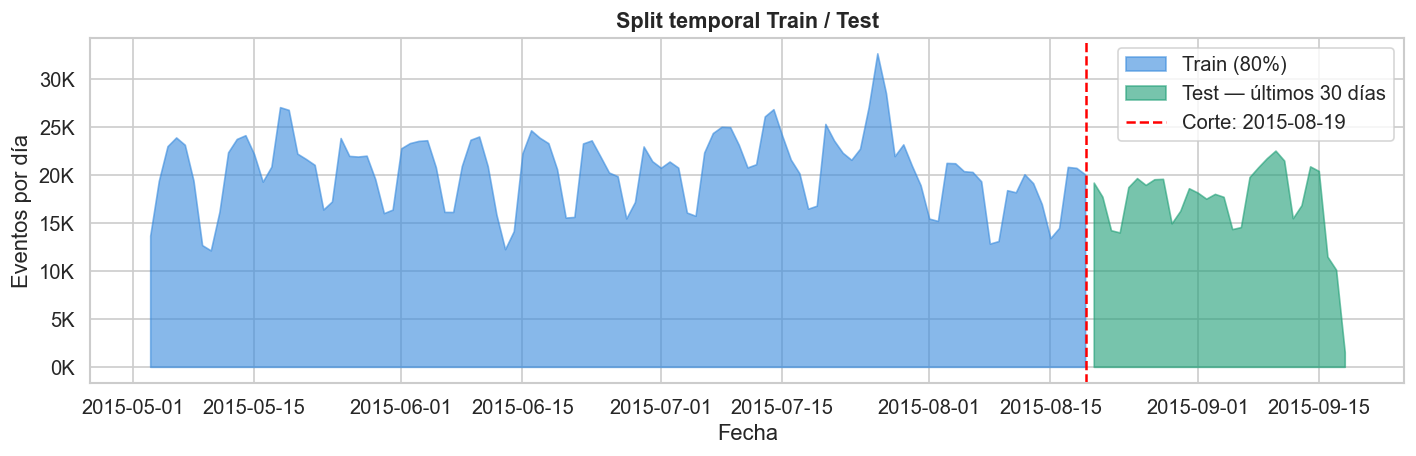

In [4]:
events_clean["date"] = events_clean["datetime"].dt.date
daily = events_clean.groupby("date")["event"].count().reset_index()
daily["date"] = pd.to_datetime(daily["date"])

cutoff = train_events["datetime"].max()

fig, ax = plt.subplots(figsize=(12, 4))
train_mask = daily["date"] <= cutoff
ax.fill_between(daily["date"], daily["event"],
                where=train_mask, alpha=0.6,
                color=COLORS["popularity"], label="Train (80%)")
ax.fill_between(daily["date"], daily["event"],
                where=~train_mask, alpha=0.6,
                color=COLORS["item_cf"], label="Test — últimos 30 días")
ax.axvline(cutoff, color="red", linestyle="--", linewidth=1.5, label=f"Corte: {cutoff.date()}")
ax.set_xlabel("Fecha")
ax.set_ylabel("Eventos por día")
ax.set_title("Split temporal Train / Test", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PRO / "sprint2_train_test_split.png", bbox_inches="tight")
plt.show()

## 3. Modelo Baseline — Popularidad Global

### 3.1 Entrenamiento

In [5]:
from src.models.popularity import PopularityRecommender

popularity_model = PopularityRecommender(top_n=10)
popularity_model.fit(events_clean=events_clean, item_profiles=item_profiles)
popularity_model.save()

print("Modelo de popularidad entrenado y guardado.")

2026-03-15 22:03:59.674 | INFO     | src.models.popularity:fit:56 - Ajustando modelo de popularidad...
2026-03-15 22:04:02.172 | INFO     | src.models.popularity:fit:95 -   Modelo ajustado: 235,061 ítems | 1,088 categorías
2026-03-15 22:04:02.175 | INFO     | src.models.popularity:fit:99 -   Top-3 ítems globales:
   itemid  popularity_score  n_transactions
0  461686              5084             133
1  187946              3418               0
2    5411              2361               0
2026-03-15 22:04:06.176 | INFO     | src.models.popularity:save:155 - Modelo guardado: D:\Work\Cursos\Data Science\Proyecto Final\recommender-system\models_saved\popularity_model.pkl


Modelo de popularidad entrenado y guardado.


### 3.2 Análisis del modelo de popularidad

In [6]:
top_items = popularity_model.global_popular.head(20)

print("Top 20 ítems más populares:")
print(top_items[["itemid", "popularity_score", "n_transactions", "category_id"]].to_string(index=False))

Top 20 ítems más populares:
 itemid  popularity_score  n_transactions category_id
 461686              5084             133        1037
 187946              3418               0        1393
   5411              2361               0         789
 320130              2227              33        1483
   7943              2194              46         398
 257040              2157              27         683
 219512              2052              12           5
 312728              2051              46        1098
 384302              1938              15           5
 309778              1907              15         683
 119736              1898              97          57
 370653              1854               0          82
  48030              1776              41        1219
 445351              1745              45        1483
 369447              1733              31          48
 234255              1682              16        1051
  37029              1665              25        1483


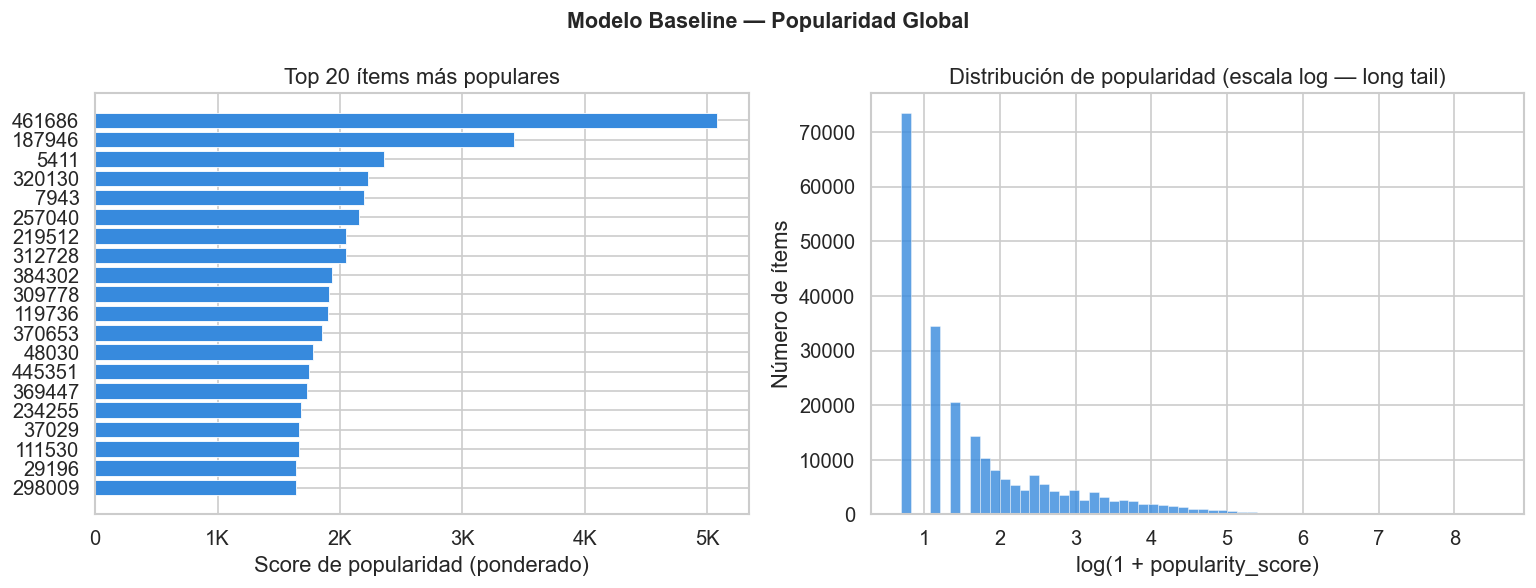

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Top 20 ítems por score
top20 = popularity_model.global_popular.head(20).copy()
top20["itemid_str"] = top20["itemid"].astype(str)

axes[0].barh(top20["itemid_str"][::-1], top20["popularity_score"][::-1],
            color=COLORS["popularity"], edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Score de popularidad (ponderado)")
axes[0].set_title("Top 20 ítems más populares")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else str(int(x))))

# Distribución de popularidad (long tail)
all_scores = popularity_model.global_popular["popularity_score"].values
axes[1].hist(np.log1p(all_scores), bins=60,
            color=COLORS["popularity"], edgecolor="white", linewidth=0.3, alpha=0.8)
axes[1].set_xlabel("log(1 + popularity_score)")
axes[1].set_ylabel("Número de ítems")
axes[1].set_title("Distribución de popularidad (escala log — long tail)")

plt.suptitle("Modelo Baseline — Popularidad Global", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "sprint2_popularity_analysis.png", bbox_inches="tight")
plt.show()

### 3.3 Ejemplo de recomendaciones del baseline

In [8]:
recs_global = popularity_model.recommend(n=10)
print("Top-10 recomendaciones globales (sin filtro de categoría):")
print(recs_global.to_string(index=False))

# Recomendación por categoría
sample_category = item_profiles["category_id"].value_counts().index[0]
recs_cat = popularity_model.recommend(category_id=sample_category, n=5)
print(f"\nTop-5 recomendaciones para categoría '{sample_category}':")
print(recs_cat.to_string(index=False))

Top-10 recomendaciones globales (sin filtro de categoría):
 itemid  score category_id  rank      model
 461686   5084        1037     1 popularity
 187946   3418        1393     2 popularity
   5411   2361         789     3 popularity
 320130   2227        1483     4 popularity
   7943   2194         398     5 popularity
 257040   2157         683     6 popularity
 219512   2052           5     7 popularity
 312728   2051        1098     8 popularity
 384302   1938           5     9 popularity
 309778   1907         683    10 popularity

Top-5 recomendaciones para categoría '342':
 itemid  score category_id  rank      model
  65273   1458         342     1 popularity
 316753   1172         342     2 popularity
 339703    948         342     3 popularity
 253615    857         342     4 popularity
  22436    720         342     5 popularity


## 4. Modelo Item-CF — Collaborative Filtering Ítem-Ítem

### 4.1 Entrenamiento

In [9]:
from src.models.item_cf import ItemCFRecommender
from config.config import EVENT_WEIGHTS, MIN_ITEM_INTERACTIONS

# Reconstruir matriz de entrenamiento (solo con datos de train)
train_matrix = (
    train_events[train_events["user_type"] == "warm"]
    .groupby(["visitorid", "itemid"])["event_weight"]
    .sum()
    .reset_index()
    .rename(columns={"event_weight": "score"})
)

# Filtrar ítems con pocas interacciones
item_counts = train_matrix.groupby("itemid")["score"].sum()
valid_items = item_counts[item_counts >= MIN_ITEM_INTERACTIONS].index
train_matrix = train_matrix[train_matrix["itemid"].isin(valid_items)]

print(f"Matriz de entrenamiento Item-CF:")
print(f"  Usuarios: {train_matrix['visitorid'].nunique():,}")
print(f"  Ítems:    {train_matrix['itemid'].nunique():,}")
print(f"  Pares:    {len(train_matrix):,}")

item_cf_model = ItemCFRecommender(top_n=10, n_neighbors=50)
item_cf_model.fit(train_matrix)
item_cf_model.save()

print("\nModelo Item-CF entrenado y guardado.")

2026-03-15 22:05:00.434 | INFO     | src.models.item_cf:fit:76 - Ajustando Item-CF...
2026-03-15 22:05:00.508 | INFO     | src.models.item_cf:fit:77 -   Usuarios: 158,553 | Ítems: 44,639


Matriz de entrenamiento Item-CF:
  Usuarios: 158,553
  Ítems:    44,639
  Pares:    562,333


2026-03-15 22:05:01.635 | INFO     | src.models.item_cf:fit:102 -   Matriz sparse: 158,553 × 44,639 | nnz: 562,333
2026-03-15 22:05:01.636 | INFO     | src.models.item_cf:fit:108 -   Calculando similitudes ítem-ítem (vecinos: 50)...
  Similitud ítems: 100%|██████████| 45/45 [01:58<00:00,  2.62s/it]
2026-03-15 22:06:59.712 | INFO     | src.models.item_cf:fit:143 -   Indexando historial de usuarios...
2026-03-15 22:07:34.698 | INFO     | src.models.item_cf:fit:155 -   Ítems con al menos 1 vecino: 43,525 / 44,639
2026-03-15 22:07:34.702 | INFO     | src.models.item_cf:fit:158 - Item-CF ajustado correctamente.
2026-03-15 22:08:32.579 | INFO     | src.models.item_cf:save:270 - Modelo guardado: D:\Work\Cursos\Data Science\Proyecto Final\recommender-system\models_saved\item_cf_model.pkl



Modelo Item-CF entrenado y guardado.


### 4.2 Análisis de similitudes ítem-ítem

In [10]:
# Distribución del número de vecinos por ítem
n_neighbors_per_item = [
    len(v) for v in item_cf_model.item_similarity.values()
]

print(f"Estadísticas de vecinos por ítem:")
print(pd.Series(n_neighbors_per_item).describe())
print(f"\nÍtems sin vecinos: {sum(1 for n in n_neighbors_per_item if n == 0):,}")
print(f"Ítems con ≥10 vecinos: {sum(1 for n in n_neighbors_per_item if n >= 10):,}")
print(f"Ítems con 50 vecinos (máximo): {sum(1 for n in n_neighbors_per_item if n == 50):,}")

Estadísticas de vecinos por ítem:
count    44639.000000
mean        36.178207
std         18.861656
min          0.000000
25%         17.000000
50%         50.000000
75%         50.000000
max         50.000000
dtype: float64

Ítems sin vecinos: 1,114
Ítems con ≥10 vecinos: 36,799
Ítems con 50 vecinos (máximo): 26,584


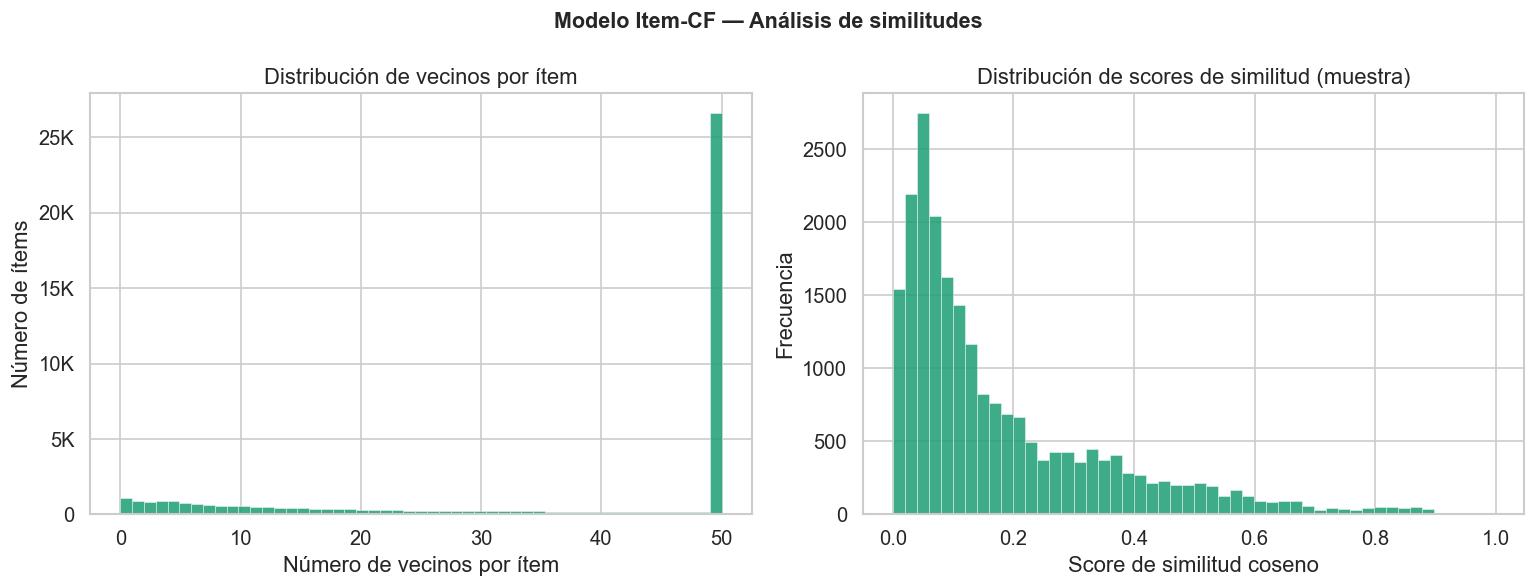

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma de vecinos por ítem
axes[0].hist(n_neighbors_per_item, bins=51,
             color=COLORS["item_cf"], edgecolor="white", linewidth=0.3, alpha=0.85)
axes[0].set_xlabel("Número de vecinos por ítem")
axes[0].set_ylabel("Número de ítems")
axes[0].set_title("Distribución de vecinos por ítem")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else str(int(x))))

# Distribución de scores de similitud (muestra de 10K)
sample_sims = []
for neighbors in list(item_cf_model.item_similarity.values())[:500]:
    sample_sims.extend([s for _, s in neighbors])

axes[1].hist(sample_sims, bins=50,
            color=COLORS["item_cf"], edgecolor="white", linewidth=0.3, alpha=0.85)
axes[1].set_xlabel("Score de similitud coseno")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de scores de similitud (muestra)")

plt.suptitle("Modelo Item-CF — Análisis de similitudes", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "sprint2_itemcf_analysis.png", bbox_inches="tight")
plt.show()

### 4.3 Ejemplo de recomendaciones Item-CF

In [12]:
# Buscar un usuario warm con suficiente historial
warm_users = [
    uid for uid, items in item_cf_model.user_item_scores.items()
    if len(items) >= 5
]
sample_user = warm_users[0] if warm_users else None

if sample_user:
    user_history = item_cf_model.user_item_scores[sample_user]
    print(f"Usuario de ejemplo: {sample_user}")
    print(f"Historial ({len(user_history)} ítems):")
    for iid, score in sorted(user_history.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  ítem {iid}: score {score}")

    recs_cf = item_cf_model.recommend(sample_user, n=10)
    print(f"\nTop-10 recomendaciones Item-CF:")
    print(recs_cf.to_string(index=False))

    # Ítems similares a uno del historial
    seed_item = list(user_history.keys())[0]
    similar = item_cf_model.recommend_similar(seed_item, n=5)
    print(f"\nÍtems similares al ítem {seed_item}:")
    print(similar.to_string(index=False))

Usuario de ejemplo: 64
Historial (6 ítems):
  ítem 160984: score 2
  ítem 118401: score 1
  ítem 141657: score 1
  ítem 224700: score 1
  ítem 233200: score 1

Top-10 recomendaciones Item-CF:
 itemid  score  rank   model
 318851 1.0000     1 item_cf
 441579 0.8440     2 item_cf
  44828 0.7957     3 item_cf
 143125 0.7659     4 item_cf
  47611 0.7443     5 item_cf
 353499 0.6347     6 item_cf
 307941 0.5704     7 item_cf
 286508 0.5635     8 item_cf
  87562 0.5263     9 item_cf
 134806 0.5020    10 item_cf

Ítems similares al ítem 118401:
 itemid  similarity_score  rank           model
 157167          0.226907     1 item_cf_similar
  36195          0.195078     2 item_cf_similar
  77735          0.187112     3 item_cf_similar
 123899          0.187112     4 item_cf_similar
 310314          0.185514     5 item_cf_similar


## 5. Evaluación Comparativa

### 5.1 Cálculo de métricas

In [13]:
from src.evaluation.metrics import evaluate_model, compare_models

catalog_size = item_profiles["itemid"].nunique()
popularity_scores = events_clean.groupby("itemid")["event_weight"].sum()

print(f"Catálogo total: {catalog_size:,} ítems")
print(f"Evaluando sobre {test_purchases['visitorid'].nunique():,} usuarios...")

# Función de recomendación para cada modelo
def rec_popularity(uid, k):
    recs = popularity_model.recommend(n=k)
    return recs["itemid"].tolist()

def rec_item_cf(uid, k):
    recs = item_cf_model.recommend(uid, n=k)
    if recs.empty:
        recs = popularity_model.recommend(n=k)
    return recs["itemid"].tolist() if not recs.empty else []

# Evaluar
print("\nEvaluando Popularity...")
metrics_pop = evaluate_model(
    recommender_fn=rec_popularity,
    test_interactions=test_purchases,
    catalog_size=catalog_size,
    popularity_scores=popularity_scores,
)

print("\nEvaluando Item-CF...")
metrics_cf = evaluate_model(
    recommender_fn=rec_item_cf,
    test_interactions=test_purchases,
    catalog_size=catalog_size,
    popularity_scores=popularity_scores,
)

2026-03-15 22:11:46.252 | INFO     | src.evaluation.metrics:evaluate_model:130 - Evaluando modelo con K=[5, 10, 20]...
2026-03-15 22:11:46.314 | INFO     | src.evaluation.metrics:evaluate_model:146 -   Evaluando sobre 860 usuarios


Catálogo total: 417,053 ítems
Evaluando sobre 860 usuarios...

Evaluando Popularity...


2026-03-15 22:12:03.456 | INFO     | src.evaluation.metrics:evaluate_model:198 - Resultados de evaluación:
2026-03-15 22:12:03.463 | INFO     | src.evaluation.metrics:evaluate_model:199 - 
 K  Precision@K  Recall@K   NDCG@K  HitRate@K  Coverage   Novelty  N_users
 5     0.006744  0.020177 0.019136   0.031395  0.000048 10.597527      860
10     0.005116  0.029557 0.021629   0.047674  0.000048 10.597527      860
20     0.003198  0.033552 0.022233   0.054651  0.000048 10.597527      860
2026-03-15 22:12:03.466 | INFO     | src.evaluation.metrics:evaluate_model:130 - Evaluando modelo con K=[5, 10, 20]...
2026-03-15 22:12:03.546 | INFO     | src.evaluation.metrics:evaluate_model:146 -   Evaluando sobre 860 usuarios



Evaluando Item-CF...


2026-03-15 22:12:12.234 | INFO     | src.evaluation.metrics:evaluate_model:198 - Resultados de evaluación:
2026-03-15 22:12:12.238 | INFO     | src.evaluation.metrics:evaluate_model:199 - 
 K  Precision@K  Recall@K   NDCG@K  HitRate@K  Coverage   Novelty  N_users
 5     0.005116  0.010315 0.008193   0.017442  0.016274 15.797731      860
10     0.003372  0.012789 0.008767   0.023256  0.016274 15.797731      860
20     0.002384  0.015925 0.009626   0.030233  0.016274 15.797731      860


### 5.2 Tabla comparativa

In [14]:
comparison = compare_models(
    {"popularity": metrics_pop, "item_cf": metrics_cf},
    k=10
)
print("\nComparativa @ K=10:")
print(comparison.to_string(index=False))

# Guardar métricas
metrics_pop["model"] = "popularity"
metrics_cf["model"]  = "item_cf"
all_metrics = pd.concat([metrics_pop, metrics_cf], ignore_index=True)
all_metrics.to_parquet(DATA_PRO / "metrics_sprint2.parquet", index=False)
print(f"\nMétricas guardadas en: {DATA_PRO / 'metrics_sprint2.parquet'}")

2026-03-15 22:12:18.338 | INFO     | src.evaluation.metrics:compare_models:231 - 
Comparativa de modelos @ K=10:
2026-03-15 22:12:18.346 | INFO     | src.evaluation.metrics:compare_models:232 - 
     Model  Precision@K  Recall@K   NDCG@K  HitRate@K  Coverage   Novelty
popularity     0.005116  0.029557 0.021629   0.047674  0.000048 10.597527
   item_cf     0.003372  0.012789 0.008767   0.023256  0.016274 15.797731



Comparativa @ K=10:
     Model  Precision@K  Recall@K   NDCG@K  HitRate@K  Coverage   Novelty
popularity     0.005116  0.029557 0.021629   0.047674  0.000048 10.597527
   item_cf     0.003372  0.012789 0.008767   0.023256  0.016274 15.797731

Métricas guardadas en: d:\Work\Cursos\Data Science\Proyecto Final\recommender-system\data\processed\metrics_sprint2.parquet


### 5.3 Visualizaciones comparativas

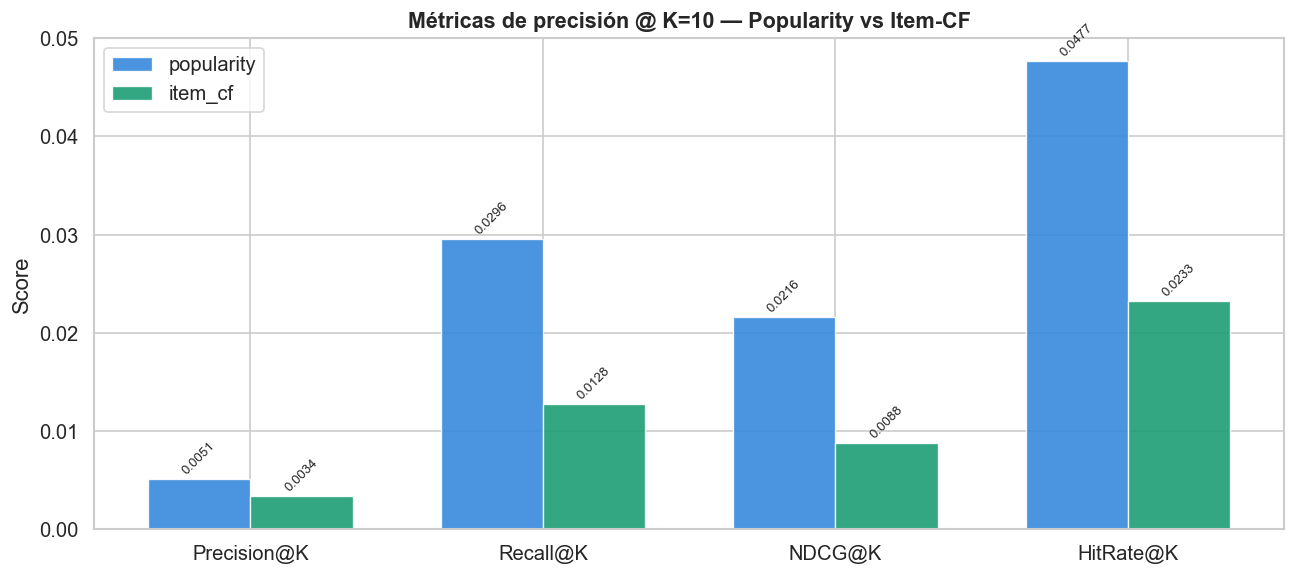

In [ ]:
# Gráfica 1: Métricas de precisión (barras agrupadas)
metrics_k10 = all_metrics[all_metrics["K"] == 10].set_index("model")
metric_cols  = ["Precision@K", "Recall@K", "NDCG@K", "HitRate@K"]
model_colors = [COLORS["popularity"], COLORS["item_cf"]]

fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(metric_cols))
width  = 0.35

for i, (model, color) in enumerate(zip(["popularity", "item_cf"], model_colors)):
    vals = [metrics_k10.loc[model, m] for m in metric_cols]
    bars = ax.bar(x + i * width, vals, width,
                label=model, color=color,
                edgecolor="white", linewidth=0.8, alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8, rotation=45)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_cols)
ax.set_ylabel("Score")
ax.set_title("Métricas de precisión @ K=10 — Popularity vs Item-CF",
            fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PRO / "sprint2_metrics_precision.png", bbox_inches="tight")
plt.show()

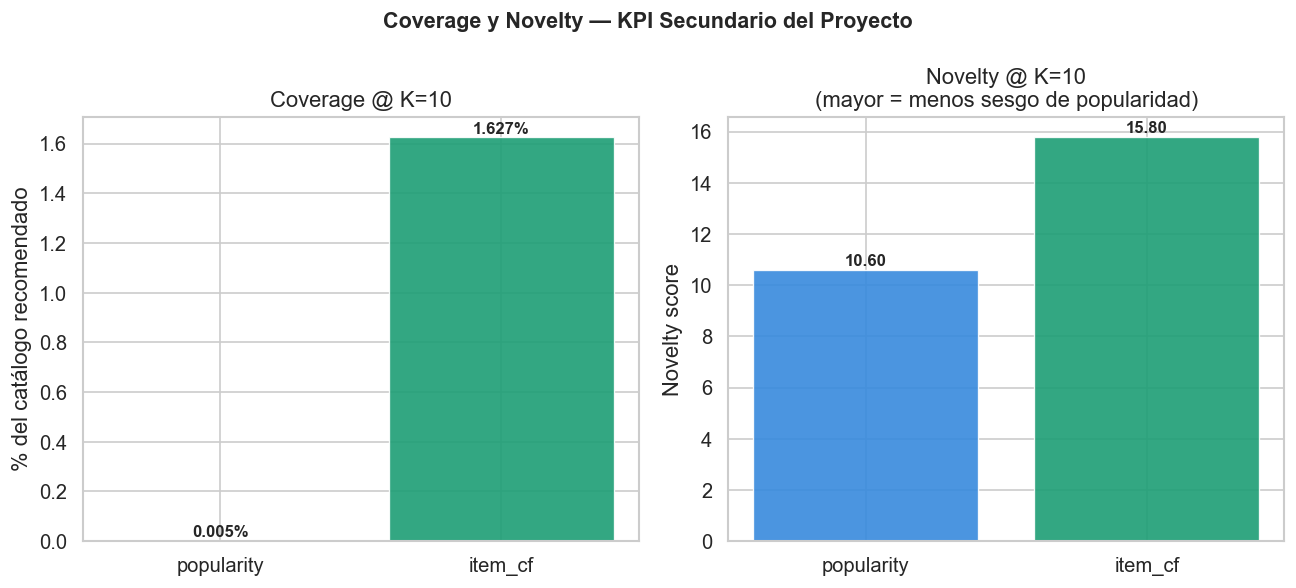

In [ ]:
# Gráfica 2: Coverage y Novelty
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

models   = ["popularity", "item_cf"]
coverage = [metrics_k10.loc[m, "Coverage"] * 100 for m in models]
novelty  = [metrics_k10.loc[m, "Novelty"] for m in models]

bars1 = axes[0].bar(models, coverage, color=model_colors,
                    edgecolor="white", linewidth=0.8, alpha=0.9)
axes[0].set_ylabel("% del catálogo recomendado")
axes[0].set_title("Coverage @ K=10")
for bar, val in zip(bars1, coverage):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

bars2 = axes[1].bar(models, novelty, color=model_colors,
                    edgecolor="white", linewidth=0.8, alpha=0.9)
axes[1].set_ylabel("Novelty score")
axes[1].set_title("Novelty @ K=10\n(mayor = menos sesgo de popularidad)")
for bar, val in zip(bars2, novelty):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f"{val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Coverage y Novelty — KPI Secundario del Proyecto",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "sprint2_coverage_novelty.png", bbox_inches="tight")
plt.show()

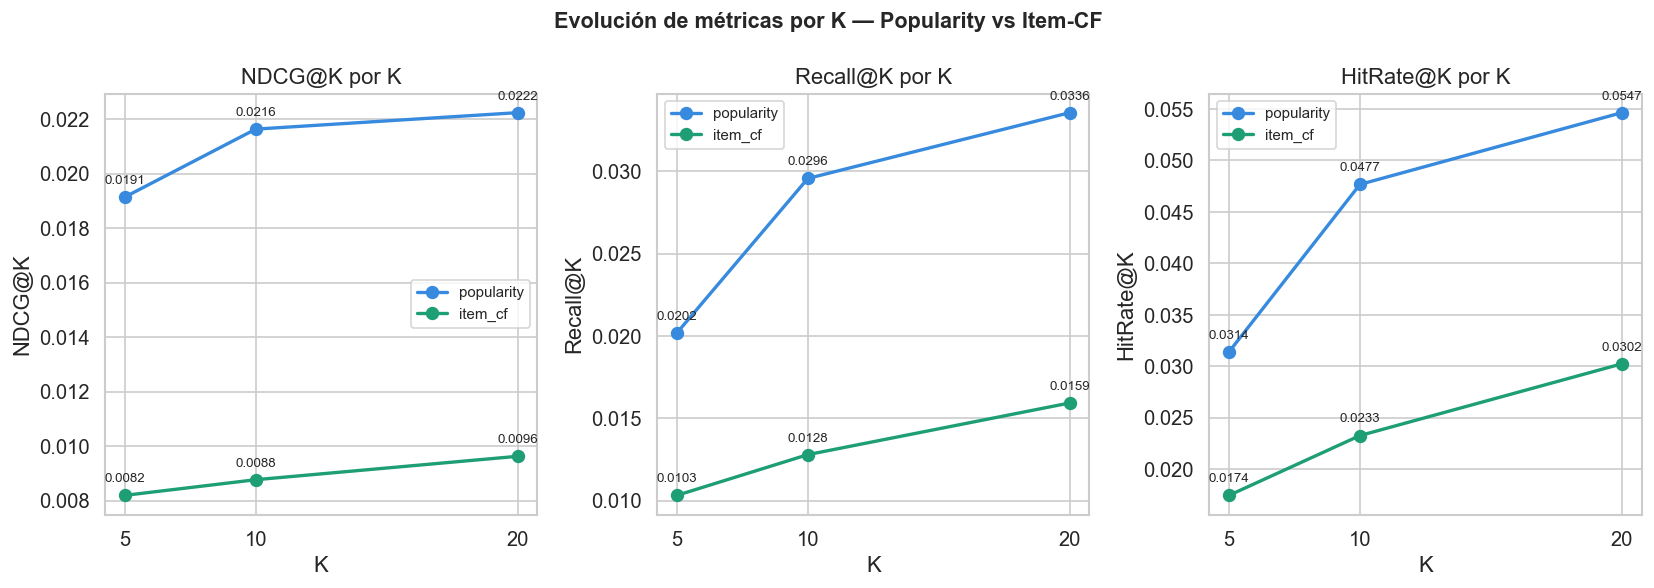

In [ ]:
# Gráfica 3: Métricas por K (curvas)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
k_vals = [5, 10, 20]

for ax, metric in zip(axes, ["NDCG@K", "Recall@K", "HitRate@K"]):
    for model, color in zip(["popularity", "item_cf"], model_colors):
        model_data = all_metrics[all_metrics["model"] == model]
        vals = [model_data[model_data["K"] == k][metric].values[0] for k in k_vals]
        ax.plot(k_vals, vals, marker="o", color=color,
                linewidth=2, markersize=7, label=model)
        for k, v in zip(k_vals, vals):
            ax.annotate(f"{v:.4f}", (k, v), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=8)
    ax.set_xlabel("K")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} por K")
    ax.set_xticks(k_vals)
    ax.legend(fontsize=9)

plt.suptitle("Evolución de métricas por K — Popularity vs Item-CF",
            fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "sprint2_metrics_by_k.png", bbox_inches="tight")
plt.show()

## 6. Análisis de Resultados

In [ ]:
print("=" * 65)
print("ANÁLISIS DE RESULTADOS — SPRINT 2")
print("=" * 65)

pop_ndcg  = metrics_k10.loc["popularity", "NDCG@K"]
cf_ndcg   = metrics_k10.loc["item_cf", "NDCG@K"]
pop_cov   = metrics_k10.loc["popularity", "Coverage"]
cf_cov    = metrics_k10.loc["item_cf", "Coverage"]
pop_nov   = metrics_k10.loc["popularity", "Novelty"]
cf_nov    = metrics_k10.loc["item_cf", "Novelty"]

print(f"""
Comparativa @ K=10:
  NDCG@10:
    Popularity: {pop_ndcg:.4f}  ← gana en precisión de ranking
    Item-CF:    {cf_ndcg:.4f}

  Coverage:
    Popularity: {pop_cov*100:.4f}%   ← recomienda siempre los mismos ítems
    Item-CF:    {cf_cov*100:.2f}%    ← {cf_cov/pop_cov:.0f}x más cobertura de catálogo

  Novelty:
    Popularity: {pop_nov:.2f}
    Item-CF:    {cf_nov:.2f}   ← {((cf_nov-pop_nov)/pop_nov*100):.0f}% menos sesgo de popularidad
""")

hallazgos = [
    ("ESPERADO",  "Popularity supera a Item-CF en precisión. Recomienda ítems"
                  " que cualquier usuario tiene alta probabilidad de ver."),
    ("CRÍTICO",   f"Coverage de Popularity es {pop_cov*100:.4f}% — prácticamente"
                  " cero. El sistema actual NO activa el catálogo invisible."),
    ("POSITIVO",  f"Item-CF tiene {cf_cov/pop_cov:.0f}x más Coverage que Popularity."
                  " Directamente ataca el KPI secundario del proyecto."),
    ("CAUSA",     "NDCG bajo en Item-CF se debe a sparsity extrema (99.99%)."
                  " ALS (Sprint 3) maneja mejor matrices sparse con feedback implícito."),
    ("SPRINT 3",  "Objetivo: ALS supere a Popularity en NDCG Y mantenga Coverage"
                  " de Item-CF. El híbrido combinará ambas fortalezas."),
]

for tag, texto in hallazgos:
    emoji = {"ESPERADO": "🔵", "CRÍTICO": "🔴", "POSITIVO": "🟢",
            "CAUSA": "🟡", "SPRINT 3": "⚪"}[tag]
    print(f"{emoji} [{tag}] {texto}\n")

print("=" * 65)
print("Artefactos generados en data/processed/:")
for f in ["sprint2_train_test_split.png", "sprint2_popularity_analysis.png",
          "sprint2_itemcf_analysis.png", "sprint2_metrics_precision.png",
          "sprint2_coverage_novelty.png", "sprint2_metrics_by_k.png",
          "metrics_sprint2.parquet"]:
    print(f"  {f}")
print("=" * 65)
print("*** Sprint 2 completado. ***")

ANÁLISIS DE RESULTADOS — SPRINT 2

Comparativa @ K=10:
  NDCG@10:
    Popularity: 0.0216  ← gana en precisión de ranking
    Item-CF:    0.0088

  Coverage:
    Popularity: 0.0048%   ← recomienda siempre los mismos ítems
    Item-CF:    1.63%    ← 339x más cobertura de catálogo

  Novelty:
    Popularity: 10.60
    Item-CF:    15.80   ← 49% menos sesgo de popularidad

🔵 [ESPERADO] Popularity supera a Item-CF en precisión. Recomienda ítems que cualquier usuario tiene alta probabilidad de ver.

🔴 [CRÍTICO] Coverage de Popularity es 0.0048% — prácticamente cero. El sistema actual NO activa el catálogo invisible.

🟢 [POSITIVO] Item-CF tiene 339x más Coverage que Popularity. Directamente ataca el KPI secundario del proyecto.

🟡 [CAUSA] NDCG bajo en Item-CF se debe a sparsity extrema (99.99%). ALS (Sprint 3) maneja mejor matrices sparse con feedback implícito.

⚪ [SPRINT 3] Objetivo: ALS supere a Popularity en NDCG Y mantenga Coverage de Item-CF. El híbrido combinará ambas fortalezas.

Artef